<a href="https://colab.research.google.com/github/SWAGAT10241/Assistant/blob/main/AI_Fashion_Design_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import os

# Download the dataset and get the path, as the previous cell was not executed.
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

# List the contents of the directory to find the data file.
print(os.listdir(path))

# Construct the full path to the CSV file, accounting for the 'fashion-dataset' subfolder.
dataset_subfolder_path = os.path.join(path, 'fashion-dataset')
csv_file_path = os.path.join(dataset_subfolder_path, 'styles.csv')

# Load the CSV file into a pandas DataFrame, handling potential parsing errors.
# Using the 'python' engine and 'on_bad_lines' to skip problematic rows.
df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')

# Display the first few rows of the DataFrame
print(df.head())

# Display information about the DataFrame
print(df.info())

100%|██████████| 23.1G/23.1G [12:59<00:00, 31.8MB/s]

Extracting files...


['fashion-dataset']


/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 6044: Expected 10 fields in line 6044, saw 11

  df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')
/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 6569: Expected 10 fields in line 6569, saw 11

  df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')
/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 7399: Expected 10 fields in line 7399, saw 11

  df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')
/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 7939: Expected 10 fields in line 7939, saw 11

  df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')
/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 9026: Expected 10 fields in line 9026, saw 11

  df = pd.read_csv(csv_file_path, engine='python', on_bad_lines='warn')
/tmp/ipython-input-850509580.py:17: ParserWarning: Skipping line 10264: Expected

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column         

In [2]:
print('The dataset has been successfully loaded into a pandas DataFrame.')

The dataset has been successfully loaded into a pandas DataFrame.


## Explore Data and Identify Outliers



In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDescriptive statistics for numerical columns:")
print(df[['id', 'year']].describe())

print("\nUnique values and their counts for categorical columns:")
for col in ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage', 'productDisplayName']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

Missing values in each column:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

Descriptive statistics for numerical columns:
                 id          year
count  44424.000000  44423.000000
mean   29696.334301   2012.806497
std    17049.490518      2.126480
min     1163.000000   2007.000000
25%    14768.750000   2011.000000
50%    28618.500000   2012.000000
75%    44683.250000   2015.000000
max    60000.000000   2019.000000

Unique values and their counts for categorical columns:

--- gender ---
gender
Men       22147
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64

--- masterCategory ---
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          10

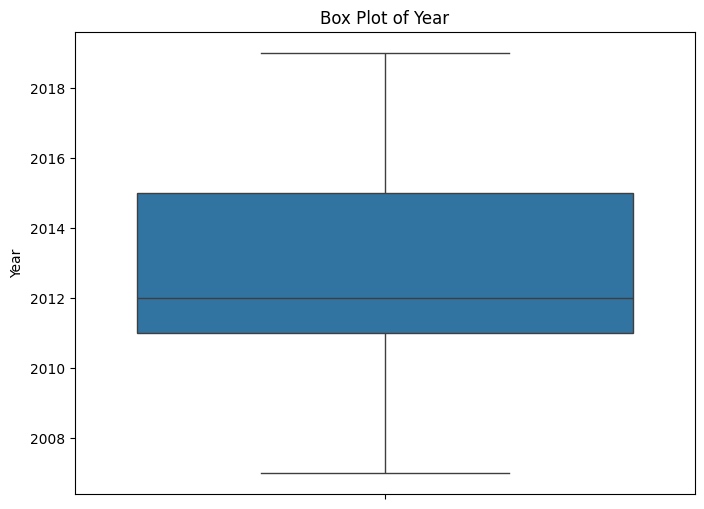

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['year'])
plt.title('Box Plot of Year')
plt.ylabel('Year')
plt.show()

## Handle Outliers

In [5]:
import numpy as np

# Identify the mode of the 'year' column
year_mode = df['year'].mode()[0]
print(f"Mode of 'year' column: {year_mode}")

# Impute missing values in 'year' column with its mode
df.fillna({'year': year_mode}, inplace=True)

# Verify that there are no remaining missing values in the 'year' column
missing_years = df['year'].isnull().sum()
print(f"Missing values in 'year' column after imputation: {missing_years}")

Mode of 'year' column: 2012.0
Missing values in 'year' column after imputation: 0


In [6]:
print("Missing values before imputation for categorical columns:")
print(df[['baseColour', 'season', 'usage', 'productDisplayName']].isnull().sum())

# Impute missing values in 'baseColour' and 'season' with their respective modes
for col in ['baseColour', 'season']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Imputed missing values in '{col}' with mode: {mode_value}")

# Verify that there are no remaining missing values in 'baseColour' and 'season'
print("\nMissing values after imputation for 'baseColour' and 'season':")
print(df[['baseColour', 'season']].isnull().sum())

Missing values before imputation for categorical columns:
baseColour             15
season                 21
usage                 317
productDisplayName      7
dtype: int64
Imputed missing values in 'baseColour' with mode: Black
Imputed missing values in 'season' with mode: Summer

Missing values after imputation for 'baseColour' and 'season':
baseColour    0
season        0
dtype: int64


In [7]:
print("Missing values before imputation for 'usage' and 'productDisplayName':")
print(df[['usage', 'productDisplayName']].isnull().sum())

# Impute missing values in 'usage' and 'productDisplayName' with their respective modes
for col in ['usage', 'productDisplayName']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"Imputed missing values in '{col}' with mode: {mode_value}")

# Verify that there are no remaining missing values in 'usage' and 'productDisplayName'
print("\nMissing values after imputation for 'usage' and 'productDisplayName':")
print(df[['usage', 'productDisplayName']].isnull().sum())

Missing values before imputation for 'usage' and 'productDisplayName':
usage                 317
productDisplayName      7
dtype: int64
Imputed missing values in 'usage' with mode: Casual
Imputed missing values in 'productDisplayName' with mode: Lucera Women Silver Earrings

Missing values after imputation for 'usage' and 'productDisplayName':
usage                 0
productDisplayName    0
dtype: int64


## Prepare Data for Prediction


In [8]:
print("Original DataFrame shape:", df.shape)

# 1. Drop the 'id' column
df = df.drop('id', axis=1)
print("DataFrame shape after dropping 'id':", df.shape)

# 2. Convert the 'year' column to an integer type
df['year'] = df['year'].astype(int)
print("Data type of 'year' column after conversion:", df['year'].dtype)

# 3. Drop the 'productDisplayName' column
df = df.drop('productDisplayName', axis=1)
print("DataFrame shape after dropping 'productDisplayName':", df.shape)

# 4. Identify all remaining categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("Identified categorical columns:", list(categorical_cols))

# 5. Apply one-hot encoding to these identified categorical columns
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nProcessed DataFrame head:")
print(df_processed.head())
print("\nProcessed DataFrame info:")
print(df_processed.info())
print("Processed DataFrame shape:", df_processed.shape)

Original DataFrame shape: (44424, 10)
DataFrame shape after dropping 'id': (44424, 9)
Data type of 'year' column after conversion: int64
DataFrame shape after dropping 'productDisplayName': (44424, 8)
Identified categorical columns: ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage']

Processed DataFrame head:
   year  gender_Girls  gender_Men  gender_Unisex  gender_Women  \
0  2011         False        True          False         False   
1  2012         False        True          False         False   
2  2016         False       False          False          True   
3  2011         False        True          False         False   
4  2012         False        True          False         False   

   masterCategory_Apparel  masterCategory_Footwear  masterCategory_Free Items  \
0                    True                    False                      False   
1                    True                    False                      False   
2       

## Build Prediction Model


In [9]:
from sklearn.model_selection import train_test_split

# 1. Select 'masterCategory' as the target variable for prediction.
y = df['masterCategory']

# 2. Create the feature matrix X by dropping all one-hot encoded 'masterCategory' columns from the 'df_processed' DataFrame.
columns_to_drop = [
    'masterCategory_Apparel',
    'masterCategory_Footwear',
    'masterCategory_Free Items',
    'masterCategory_Home',
    'masterCategory_Personal Care',
    'masterCategory_Sporting Goods'
]
X = df_processed.drop(columns=columns_to_drop)

# Identify and filter out classes with only one sample from y and X
# The 'Home' category has only 1 sample, which causes issues with stratification.
value_counts = y.value_counts()
single_sample_classes = value_counts[value_counts == 1].index.tolist()

if single_sample_classes:
    print(f"Removing rows where 'masterCategory' is in: {single_sample_classes} due to single sample for stratification.")
    # Get indices of rows to keep
    indices_to_keep = ~y.isin(single_sample_classes)
    X = X[indices_to_keep]
    y = y[indices_to_keep]

# 3. Split the data into training and testing sets (e.g., 80% training, 20% testing) using train_test_split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Removing rows where 'masterCategory' is in: ['Home'] due to single sample for stratification.
Shape of X_train: (35538, 246)
Shape of X_test: (8885, 246)
Shape of y_train: (35538,)
Shape of y_test: (8885,)


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Evaluate Model Performance

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.9999

Classification Report:
                precision    recall  f1-score   support

   Accessories       1.00      1.00      1.00      2255
       Apparel       1.00      1.00      1.00      4279
      Footwear       1.00      1.00      1.00      1844
    Free Items       1.00      1.00      1.00        21
 Personal Care       1.00      1.00      1.00       481
Sporting Goods       1.00      1.00      1.00         5

      accuracy                           1.00      8885
     macro avg       1.00      1.00      1.00      8885
  weighted avg       1.00      1.00      1.00      8885


Confusion Matrix:
[[2254    0    0    0    1    0]
 [   0 4279    0    0    0    0]
 [   0    0 1844    0    0    0]
 [   0    0    0   21    0    0]
 [   0    0    0    0  481    0]
 [   0    0    0    0    0    5]]


# "Fashion Trends"

In [12]:
print("Original DataFrame head:")
print(df.head())

# 1. Aggregate the df DataFrame by the 'year' column and the 'masterCategory' column.
#    Count the number of products for each unique combination of year and master category.
product_counts_by_year_category = df.groupby(['year', 'masterCategory']).size()

# 2. Reset the index of the resulting aggregated data to convert it into a DataFrame.
df_time_series = product_counts_by_year_category.reset_index()

# 3. Rename the column containing the product counts to `product_count` for clarity.
df_time_series.rename(columns={0: 'product_count'}, inplace=True)

# 4. Display the first few rows of the newly created time-series DataFrame to inspect its structure.
print("\nTime-series DataFrame head:")
print(df_time_series.head())

# 5. Print the information about the new DataFrame using .info() to check data types and non-null counts.
print("\nTime-series DataFrame info:")
print(df_time_series.info())

Original DataFrame head:
  gender masterCategory subCategory  articleType baseColour  season  year  \
0    Men        Apparel     Topwear       Shirts  Navy Blue    Fall  2011   
1    Men        Apparel  Bottomwear        Jeans       Blue  Summer  2012   
2  Women    Accessories     Watches      Watches     Silver  Winter  2016   
3    Men        Apparel  Bottomwear  Track Pants      Black    Fall  2011   
4    Men        Apparel     Topwear      Tshirts       Grey  Summer  2012   

    usage  
0  Casual  
1  Casual  
2  Casual  
3  Casual  
4  Casual  

Time-series DataFrame head:
   year masterCategory  product_count
0  2007       Footwear              2
1  2008    Accessories              3
2  2008        Apparel              1
3  2008       Footwear              3
4  2009    Accessories              3

Time-series DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ---

In [13]:
import pandas as pd

# 1. Convert the 'year' column to a datetime object, representing the start of each year.
df_time_series['year'] = pd.to_datetime(df_time_series['year'], format='%Y')

# 2. Create a complete, continuous time range for all unique masterCategory values.
min_year = df_time_series['year'].min().year
max_year = df_time_series['year'].max().year
all_years = pd.to_datetime([f'{y}-01-01' for y in range(min_year, max_year + 1)])
all_categories = df_time_series['masterCategory'].unique()

# Create a MultiIndex for all possible year-category combinations
full_idx = pd.MultiIndex.from_product([all_years, all_categories], names=['year', 'masterCategory'])

# 3. Reindex the df_time_series DataFrame to include all combinations of years and masterCategory values.
#    Fill any newly introduced missing 'product_count' values with 0.
df_time_series = df_time_series.set_index(['year', 'masterCategory']).reindex(full_idx, fill_value=0).reset_index()

# 4. Display the first few rows of the newly created time-series DataFrame to inspect its structure.
print("\nUpdated Time-series DataFrame head:")
print(df_time_series.head())

# 5. Print the information about the new DataFrame using .info() to check data types and non-null counts.
print("\nUpdated Time-series DataFrame info:")
print(df_time_series.info())


Updated Time-series DataFrame head:
        year  masterCategory  product_count
0 2007-01-01        Footwear              2
1 2007-01-01     Accessories              0
2 2007-01-01         Apparel              0
3 2007-01-01      Free Items              0
4 2007-01-01  Sporting Goods              0

Updated Time-series DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   year            91 non-null     datetime64[ns]
 1   masterCategory  91 non-null     object        
 2   product_count   91 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.3+ KB
None


## Feature Engineering for Trend Prediction


In [14]:
print("Original df_time_series head:")
print(df_time_series.head())

# 1. Convert the 'year' column to a numerical representation (integer year)
df_time_series['year_int'] = df_time_series['year'].dt.year
print(f"Data type of 'year_int' column after conversion: {df_time_series['year_int'].dtype}")

# Sort the DataFrame to ensure correct calculation of lagged and rolling features
df_time_series = df_time_series.sort_values(by=['masterCategory', 'year'])

# 2. Create lagged features for 'product_count' grouped by 'masterCategory'
#    Lag 1: previous year's product count
df_time_series['product_count_lag_1'] = df_time_series.groupby('masterCategory')['product_count'].shift(1)

# 3. Calculate a rolling mean (moving average) of 'product_count' grouped by 'masterCategory'
#    Using a window of 2 years for demonstration
df_time_series['product_count_roll_mean_2'] = df_time_series.groupby('masterCategory')['product_count'].rolling(window=2, min_periods=1).mean().reset_index(level=0, drop=True)

# 4. Convert the 'masterCategory' column into a numerical representation using one-hot encoding.
df_time_series_engineered = pd.get_dummies(df_time_series, columns=['masterCategory'], prefix='category', drop_first=True)

# Drop the original 'year' datetime column as 'year_int' is now available
df_time_series_engineered = df_time_series_engineered.drop(columns=['year'])

# 5. Display the first few rows of the DataFrame with the newly engineered features.
print("\nDataFrame with engineered features head:")
print(df_time_series_engineered.head())

# Display information about the new DataFrame using .info()
print("\nDataFrame with engineered features info:")
print(df_time_series_engineered.info())

Original df_time_series head:
        year  masterCategory  product_count
0 2007-01-01        Footwear              2
1 2007-01-01     Accessories              0
2 2007-01-01         Apparel              0
3 2007-01-01      Free Items              0
4 2007-01-01  Sporting Goods              0
Data type of 'year_int' column after conversion: int32

DataFrame with engineered features head:
    product_count  year_int  product_count_lag_1  product_count_roll_mean_2  \
1               0      2007                  NaN                        0.0   
8               3      2008                  0.0                        1.5   
15              3      2009                  3.0                        3.0   
22            108      2010                  3.0                       55.5   
29           1167      2011                108.0                      637.5   

    category_Apparel  category_Footwear  category_Free Items  category_Home  \
1              False              False                

## Train Time-Series Model

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

print("Original df_time_series_engineered head:")
print(df_time_series_engineered.head())

# 1. Define the features (X) and target variable (y)
X = df_time_series_engineered.drop(columns=['product_count'])
y = df_time_series_engineered['product_count']

# 2. Drop any rows with NaN values introduced by lagged features from both X and y
#    Create a temporary DataFrame to align dropping NaNs from X and y
combined_df = pd.concat([X, y], axis=1)
combined_df_cleaned = combined_df.dropna()

X_cleaned = combined_df_cleaned.drop(columns=['product_count'])
y_cleaned = combined_df_cleaned['product_count']

print(f"\nShape of X after dropping NaNs: {X_cleaned.shape}")
print(f"Shape of y after dropping NaNs: {y_cleaned.shape}")

# 3. Split the data into training and testing sets chronologically (80% train, 20% test)
split_index = int(len(X_cleaned) * 0.8)

X_train = X_cleaned.iloc[:split_index]
X_test = X_cleaned.iloc[split_index:]
y_train = y_cleaned.iloc[:split_index]
y_test = y_cleaned.iloc[split_index:]

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 4. Initialize a RandomForestRegressor model
model_time_series = RandomForestRegressor(random_state=42)

# 5. Train the model using the training data
model_time_series.fit(X_train, y_train)

print("\nRandomForestRegressor model for time-series trained successfully.")

Original df_time_series_engineered head:
    product_count  year_int  product_count_lag_1  product_count_roll_mean_2  \
1               0      2007                  NaN                        0.0   
8               3      2008                  0.0                        1.5   
15              3      2009                  3.0                        3.0   
22            108      2010                  3.0                       55.5   
29           1167      2011                108.0                      637.5   

    category_Apparel  category_Footwear  category_Free Items  category_Home  \
1              False              False                False          False   
8              False              False                False          False   
15             False              False                False          False   
22             False              False                False          False   
29             False              False                False          False   

    categ

## Forecast Future Trends

In [16]:
y_pred_time_series = model_time_series.predict(X_test)
print("Predictions for future fashion trends generated successfully.")
print("First 5 predictions:", y_pred_time_series[:5])

Predictions for future fashion trends generated successfully.
First 5 predictions: [0.00000e+00 5.10000e-01 1.26289e+03 8.38450e+02 1.24200e+01]


## Evaluate Trend Forecasts



In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_time_series)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_time_series))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 116.55
Root Mean Squared Error (RMSE): 336.68


## Visualize Trends and Forecasts

Unique categories identified for plotting: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Home', 'Personal Care', 'Sporting Goods']


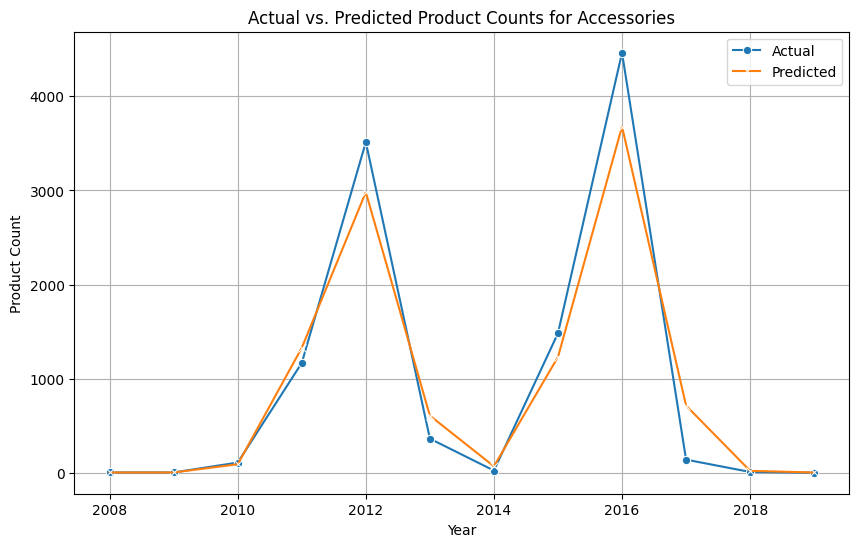

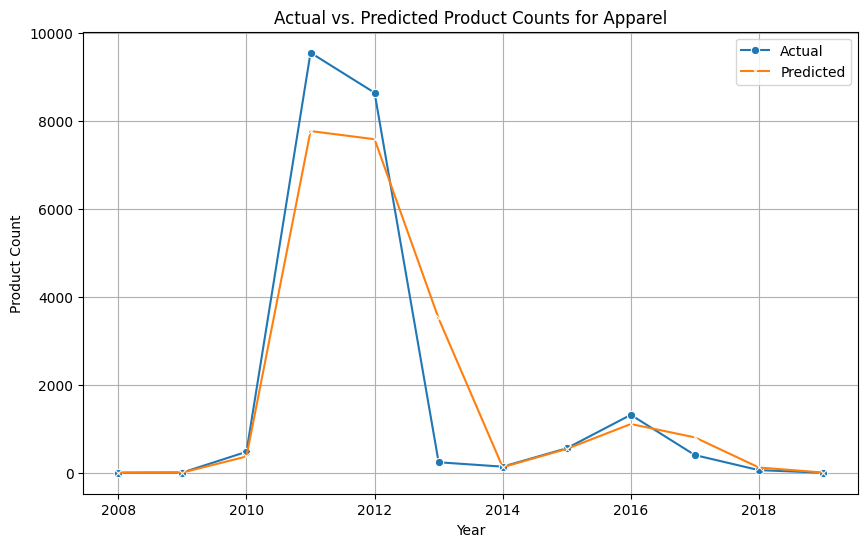

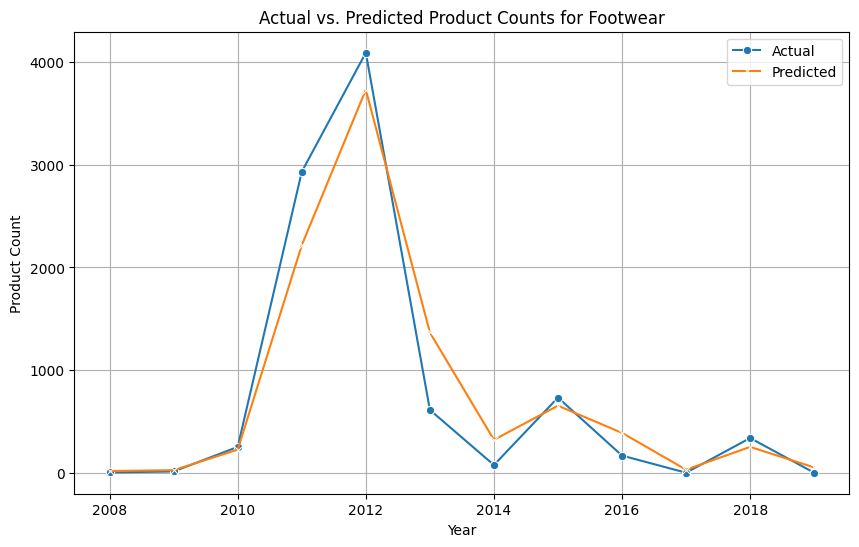

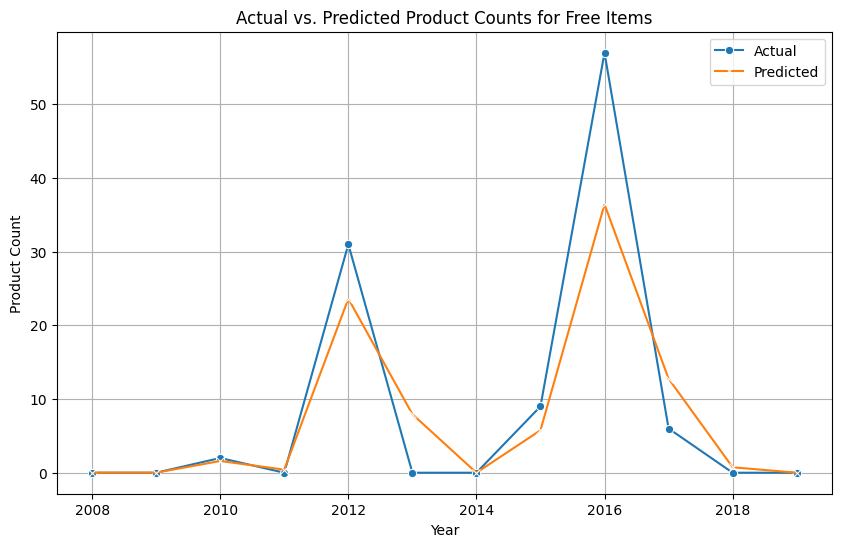

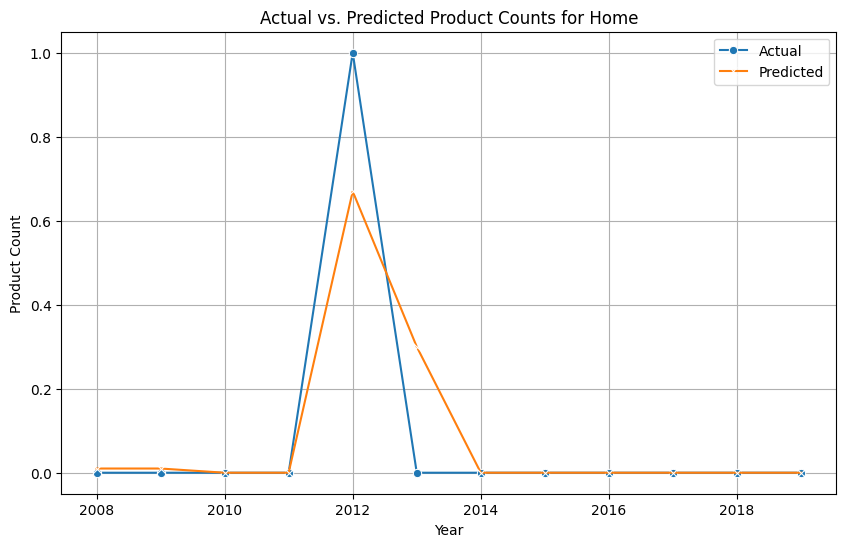

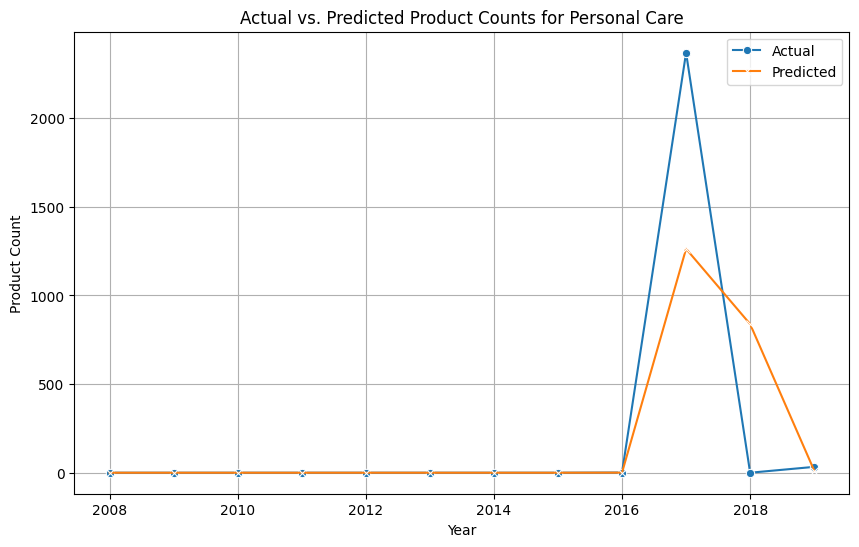

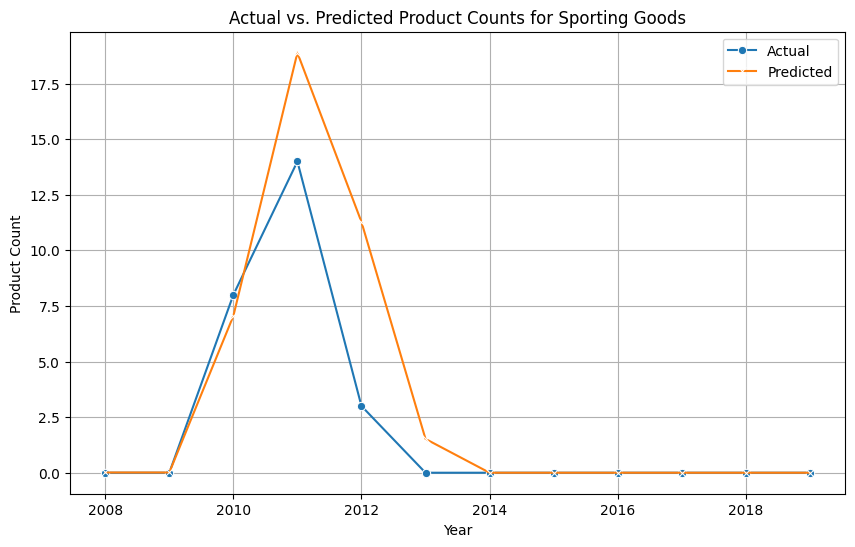

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the entire cleaned dataset
predictions_full = model_time_series.predict(X_cleaned)

# Reconstruct the masterCategory column for all data points in X_cleaned
def get_master_category_from_dummies(row, category_cols):
    for col in category_cols:
        if row[col]:
            return col.replace('category_', '')
    # If none of the dummy columns are True, it means it's the base category
    # which was dropped by drop_first=True. In this case, 'Accessories'.
    return 'Accessories'

# Get the list of category dummy columns from X_cleaned
category_dummy_cols = [col for col in X_cleaned.columns if col.startswith('category_')]

# Reset index of X_cleaned and y_cleaned for proper alignment
X_cleaned_reset = X_cleaned.reset_index(drop=True)
y_cleaned_reset = y_cleaned.reset_index(drop=True)

# Apply the function to reconstruct masterCategory
full_category_series = X_cleaned_reset.apply(lambda row: get_master_category_from_dummies(row, category_dummy_cols), axis=1)

# Create a new DataFrame for plotting that includes year_int, reconstructed masterCategory, actual, and predicted values
plot_all_df = pd.DataFrame({
    'year_int': X_cleaned_reset['year_int'],
    'masterCategory': full_category_series,
    'actual_product_count': y_cleaned_reset,
    'predicted_product_count': predictions_full
})

# Get a list of all unique masterCategory values
unique_categories_all = plot_all_df['masterCategory'].unique()
print(f"Unique categories identified for plotting: {list(unique_categories_all)}")

# Iterate through each unique masterCategory and generate a separate line plot
for category in unique_categories_all:
    category_df_all = plot_all_df[plot_all_df['masterCategory'] == category]

    plt.figure(figsize=(10, 6))
    sns.lineplot(x='year_int', y='actual_product_count', data=category_df_all, label='Actual', marker='o')
    sns.lineplot(x='year_int', y='predicted_product_count', data=category_df_all, label='Predicted', marker='x')

    plt.title(f'Actual vs. Predicted Product Counts for {category}')
    plt.xlabel('Year')
    plt.ylabel('Product Count')
    plt.legend()
    plt.grid(True)
    plt.show()